In [171]:
#2. Exploratory Data Analysis(EDA)
# a. Dataset overview and summary statistics 
#Load dataset
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
data = pd.read_csv('sri_lanka_it_jobs_dataset.csv')
data.head()

,Role,Soft Skills,Tech Stack,Experience (Years),Salary Range (LKR/Month)
0,Software Engineer (Full-Stack),"Problem-solving, Communication, Team collabora...","JavaScript/TypeScript, React, Node.js, HTML/CS...","0-2 (Entry), 3-5 (Mid), 6+ (Senior)","120,000-180,000 (Entry) | 180,000-300,000 (Mid..."
1,Frontend Developer,"User empathy, Communication, Attention to deta...","HTML5, CSS3, JavaScript/TypeScript, React/Vue/...","0-2 (Entry), 3-5 (Mid), 6+ (Senior)","80,000-120,000 (Entry) | 120,000-200,000 (Mid)..."
2,Backend Developer,"Problem-solving, System design thinking, Commu...","Node.js, Python, Java, .NET, Express, Django, ...","0-2 (Entry), 3-5 (Mid), 6+ (Senior)","100,000-150,000 (Entry) | 150,000-250,000 (Mid..."
3,Mobile Developer (iOS/Android),"Attention to detail, Problem-solving, Adaptabi...","Swift/Kotlin, Android Studio, iOS SDK, React N...","0-2 (Entry), 3-5 (Mid), 6+ (Senior)","90,000-140,000 (Entry) | 140,000-250,000 (Mid)..."
4,Flutter Developer,"Problem-solving, Adaptability, Communication, ...","Flutter, Dart, Firebase, REST APIs, Mobile UI/...","0-2 (Entry), 2-4 (Mid), 5+ (Senior)","80,000-130,000 (Entry) | 130,000-220,000 (Mid)..."


In [161]:
# Shape of Dataset
print(data.shape)

(209, 5)


In [160]:
#Column names
data.columns

Index(['Role', 'Soft Skills', 'Tech Stack', 'Experience (Years)',
       'Salary Range (LKR/Month)'],
      dtype='str')

In [159]:
# a. summary statistics 
data.describe(include = 'all')

,Role,Soft Skills,Tech Stack,Experience (Years),Salary Range (LKR/Month)
count,209,209,209,209,209
unique,209,160,100,22,55
top,Software Engineer (Full-Stack),"Communication, Organizational skills, Problem-...","JavaScript/TypeScript, React/Vue, Node.js, HTM...",Fresh graduate / Final year student,"0-25,000 (Unpaid) | 25,000-50,000 (Paid intern..."
freq,1,50,61,102,61


In [172]:
# b. Missing value, Duplicate data analysis 
data.isnull().sum()

Role                        0
Soft Skills                 0
Tech Stack                  0
Experience (Years)          0
Salary Range (LKR/Month)    0
dtype: int64

In [163]:
data.duplicated().sum()

np.int64(0)

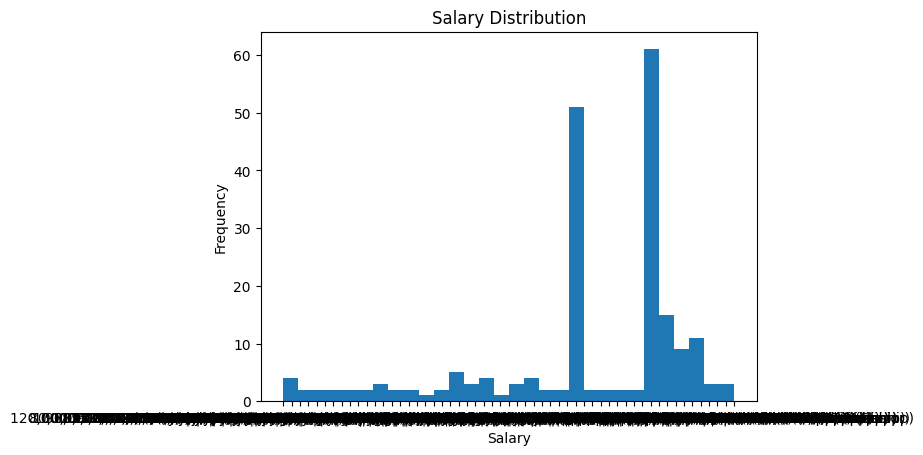

In [173]:
#c. Feature(Salary) distributions 
import matplotlib.pyplot as plt
plt.hist(data['Salary Range (LKR/Month)'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

In [174]:
# 3. Data Preprocessing 
# a. Handling missing values, duplicate data, single value columns, outliers (if any)
# a . Remove single valuue columns
single_value_cols = data.columns[data.nunique() == 1]
print("Single value columns", list(single_value_cols))
print()

Single value columns []



In [175]:
# drop them
data_clean = data.drop(columns=single_value_cols)
# check new shape
print("Original shape:", data.shape)
print("Cleaned shape:", data_clean.shape)

Original shape: (209, 5)
Cleaned shape: (209, 5)


In [176]:
#calculate dulpicates
dups = data.duplicated()
#List all duplicate rows
print(data[dups])

Empty DataFrame
Columns: [Role, Soft Skills, Tech Stack, Experience (Years), Salary Range (LKR/Month)]
Index: []


In [177]:
#delete duplicate rows
data.drop_duplicates(inplace = True)
print(data.shape)

(209, 5)


In [ ]:
# Handle missing values 
for col in data.columns:
    if data[col].dtype in ['float64', 'int64']:
        data[col] = data[col].fillna(data[col].mean())   # numeric to mean
    else:
        data[col] = data[col].fillna(data[col].mode()[0])  # categorical to mode
print(data.isnull().sum())

In [178]:
#Outlier

numeric_columns = data.select_dtypes(include=['float64', 'int64']).columns
data_numeric = data[numeric_columns]# Compute IQR and detect outliers feature-wise 
outlier_indices = []

for col in numeric_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_col = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
    outlier_indices.extend(outlier_col)

outlier_indices = list(set(outlier_indices))

print("Total outlier row detected: ",  len(outlier_indices))

data.drop(index = outlier_indices, inplace=True)

Total outlier row detected:  0


In [179]:
# This function converts the string range into a single numeric value
def convert_salary(x):
    nums = x.split("(")[0].replace(",", "").split("-")
    return (int(nums[0]) + int(nums[1])) / 2

data['Salary'] = data['Salary Range (LKR/Month)'].apply(convert_salary)

In [180]:
# b. test Train–data splitting 

X = data.drop(columns=['Salary Range (LKR/Month)','Salary'])
y = data['Salary']

(array([102.,   0.,   0.,   0.,   0.,   2.,   0.,   2.,   3.,   5.,  56.,
          9.,   3.,   0.,   4.,   4.,   6.,   1.,   4.,   2.,   1.,   1.,
          0.,   2.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([  9000.,  18700.,  28400.,  38100.,  47800.,  57500.,  67200.,
         76900.,  86600.,  96300., 106000., 115700., 125400., 135100.,
        144800., 154500., 164200., 173900., 183600., 193300., 203000.,
        212700., 222400., 232100., 241800., 251500., 261200., 270900.,
        280600., 290300., 300000.]),
 <BarContainer object of 30 artists>)

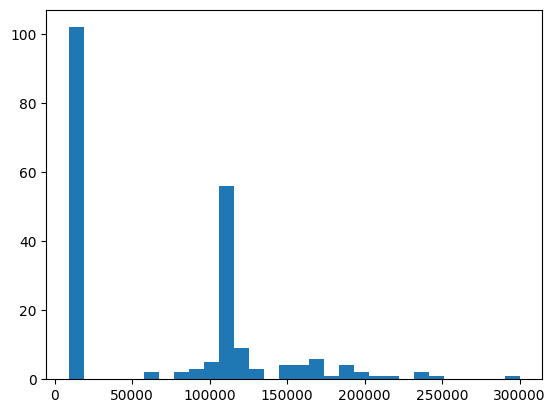

In [181]:
plt.hist(data['Salary'], bins=30)


In [182]:
#b. test Train–data splitting 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [186]:
# Separate numeric & categorical columns
#num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
#cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns

print("Numeric columns:", list(num_cols))
print("Categorical columns:", list(cat_cols))

Numeric columns: []
Categorical columns: ['Role', 'Soft Skills', 'Tech Stack', 'Experience (Years)']


In [187]:
#c. Encoding categorical variables 
# i used one hot encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_enc = encoder.fit_transform(X_train[cat_cols])
X_test_enc = encoder.transform(X_test[cat_cols])

# Since no numeric columns exist
X_train_final = X_train_cat
X_test_final = X_test_cat

In [ ]:
#d. Feature scaling (if required) -- no need bcz my dataset currently has only categorical features. thearefore, i musn't use StandardScaler

In [184]:
print(X_train.dtypes)

Role                  str
Soft Skills           str
Tech Stack            str
Experience (Years)    str
dtype: object


In [146]:
#4. Model Development 

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train_enc, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [189]:
#5. Model Evaluation and prediction 
y_pred = model.predict(X_test_enc)

In [148]:
#ii. Regression: MAE, MSE, RMSE, R² 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)


Model Performance
MAE : 5678.085046492981
MSE : 237641154.4506073
RMSE: 15415.613982278075
R2 : 0.9454184666855264


In [150]:
print(y.head())

0    150000.0
1    100000.0
2    125000.0
3    115000.0
4    105000.0
Name: Salary, dtype: float64


In [107]:
print(y.isnull().sum())

0


In [191]:
print("First 5 Salary Values:")
print(y.head())

print("Null Salary Count:", y.isnull().sum())

First 5 Salary Values:
0    150000.0
1    100000.0
2    125000.0
3    115000.0
4    105000.0
Name: Salary, dtype: float64
Null Salary Count: 0


In [194]:
#b. Interpret and discuss results and do prediction on new data. 


new_data = pd.DataFrame({
    "Role": ["Data Analyst"],
    "Soft Skills": ["Problem Solving, Teamwork"],
    "Tech Stack": ["Python, SQL, Excel"],
    "Experience (Years)": ["2"]
})

# Encode using SAME encoder
new_data_enc = encoder.transform(new_data)

# Predict
predicted_salary = model.predict(new_data_enc)

print("\nPredicted Salary for New Candidate:")
print("LKR", round(predicted_salary[0], 2))


Predicted Salary for New Candidate:
LKR 128653.85


In [196]:
import joblib

joblib.dump(model, "salary_model.pkl")
joblib.dump(encoder, "encoder.pkl")

print("Model and Encoder saved successfully!")

Model and Encoder saved successfully!
